# NA Study Demo

This notebook demonstrates the report-facing NA study workflow. It imports only `fourier_optics.na_study` as the project analysis package.

The intended production data shape is a plain dictionary:

```python
data_fdtd = {
    "h1w40": mat_1,
    "h2.5w60": mat_2,
    "h4w80": mat_3,
}
```

Plotting functions take `data_fdtd` plus a list of `keys`, so you can flexibly swap in work-environment FDTD matrices without rebuilding custom objects.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

import fourier_optics.na_study as nas

output_dir = repo_root / "outputs"
output_dir.mkdir(exist_ok=True)

## Study Parameters

The optical collection band is the PO annulus `NA = 0.10-0.28`. The demo analyzes scattered defect signal by subtracting a flat reference field, `reference_field=1.0`.

In [2]:
pixel_size_um = 0.001
wavelength_um = 0.0135
na_inner = 0.10
na_outer = 0.28
reference_field = 1.0

data_fdtd = nas.make_demo_fdtd_dict(
    heights_nm=(1.0, 2.5, 4.0),
    widths_nm=(40.0, 50.0, 60.0, 80.0, 100.0),
    shape=(512, 512),
    pixel_size_um=pixel_size_um,
    wavelength_um=wavelength_um,
    profile="gaussian",
)
keys = list(data_fdtd.keys())

print(f"Demo matrices: {len(data_fdtd)}")
print(f"First keys: {keys[:5]}")
print(f"Matrix shape: {data_fdtd[keys[0]].shape}")
print(f"Collection NA: {na_inner:.2f}-{na_outer:.2f}")

Demo matrices: 15
First keys: ['h1w40', 'h1w50', 'h1w60', 'h1w80', 'h1w100']
Matrix shape: (512, 512)
Collection NA: 0.10-0.28


## Single-Matrix Interfaces

These are the three primitive calls used by the rest of the report workflow.

In [3]:
key = "h1w40"
po_energy = nas.collected_na_energy_from_dict(
    data_fdtd,
    key,
    pixel_size_um=pixel_size_um,
    wavelength_um=wavelength_um,
    na_inner=na_inner,
    na_outer=na_outer,
    reference_field=reference_field,
)
pupil = nas.pupil_energy_distribution(
    data_fdtd[key],
    pixel_size_um=pixel_size_um,
    wavelength_um=wavelength_um,
    reference_field=reference_field,
)
r_na_norm, rho_norm = nas.radial_energy_density(
    data_fdtd[key],
    pixel_size_um=pixel_size_um,
    wavelength_um=wavelength_um,
    normalize=True,
    reference_field=reference_field,
)
r_na_abs, rho_abs = nas.radial_energy_density(
    data_fdtd[key],
    pixel_size_um=pixel_size_um,
    wavelength_um=wavelength_um,
    normalize=False,
    reference_field=reference_field,
)

print(f"Key: {key}")
print(f"Collected PO energy: {po_energy:.8e}")
print(f"Pupil map shape: {pupil.energy.shape}")
print(f"Radial bins: {len(r_na_abs)}")
print(f"Normalized density integral: {(rho_norm * (r_na_norm[1] - r_na_norm[0])).sum():.8f}")

Key: h1w40
Collected PO energy: 5.82720532e-07
Pupil map shape: (512, 512)
Radial bins: 363
Normalized density integral: 1.00000000


## Pupil and 1D NA Comparison

This page compares several FDTD matrices directly. The 2D maps show pupil energy; the 1D plot overlays absolute radial energy density so the PO-entering energy can be compared without normalization.

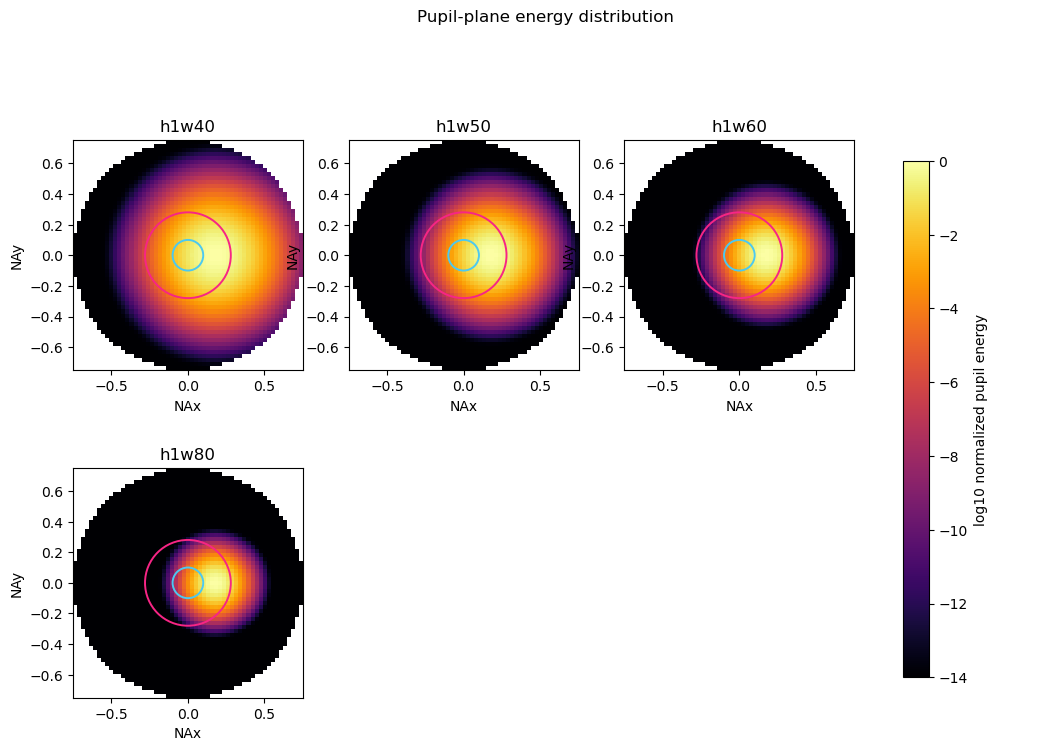

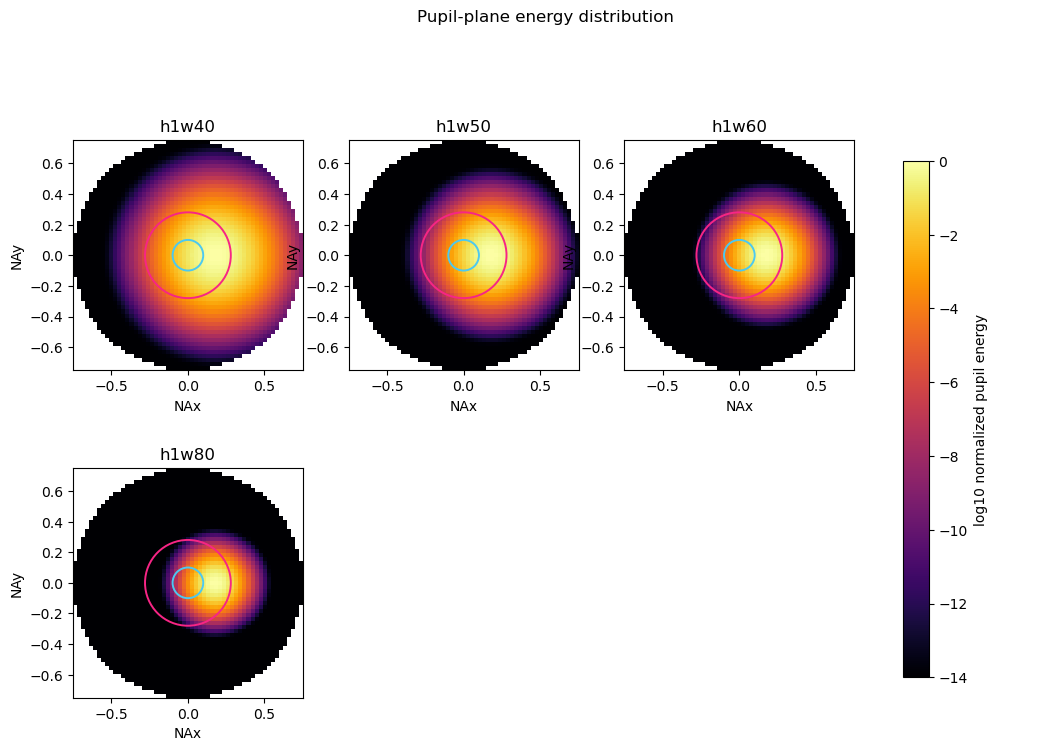

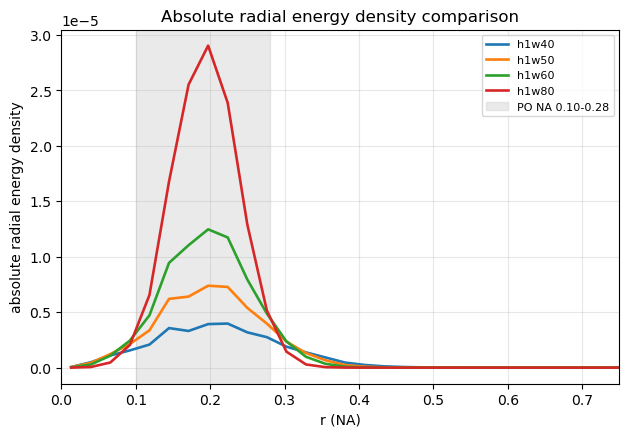

In [4]:
selected_keys = ["h1w40", "h1w50", "h1w60", "h1w80"]
fig_maps, fig_radial = nas.plot_fdtd_dict_pupil_and_radial(
    data_fdtd,
    selected_keys,
    pixel_size_um=pixel_size_um,
    wavelength_um=wavelength_um,
    na_inner=na_inner,
    na_outer=na_outer,
    reference_field=reference_field,
    max_na=0.75,
)
fig_maps.savefig(output_dir / "na_study_demo_pupil_maps.png", dpi=180, bbox_inches="tight")
fig_radial.savefig(output_dir / "na_study_demo_radial_density.png", dpi=180, bbox_inches="tight")
fig_maps

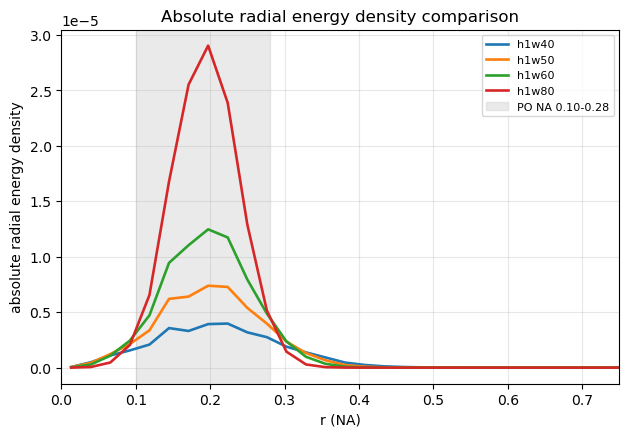

In [5]:
fig_radial

## PO Energy Table

The collected energy is integrated over `0.10 <= NA <= 0.28`. SEVD is computed from the Gaussian height and FWHM width metadata.

In [6]:
print("key       h_nm  w_nm  SEVD_nm  collected_energy")
for case in nas.cases_from_fdtd_dict(data_fdtd, keys):
    energy = nas.collected_na_energy(
        case.field,
        pixel_size_um=pixel_size_um,
        wavelength_um=wavelength_um,
        na_inner=na_inner,
        na_outer=na_outer,
        reference_field=reference_field,
    )
    print(f"{case.title:8s}  {case.height_nm:4.1f}  {case.width_nm:5.1f}  {case.sevd_nm:7.3f}  {energy:16.8e}")

key       h_nm  w_nm  SEVD_nm  collected_energy
h1w40      1.0   40.0   15.128    5.82720532e-07
h1w50      1.0   50.0   17.555    1.03545076e-06
h1w60      1.0   60.0   19.824    1.62351818e-06
h1w80      1.0   80.0   24.015    3.14514324e-06
h1w100     1.0  100.0   27.867    5.05451337e-06
h2.5w40    2.5   40.0   20.533    3.64200333e-06
h2.5w50    2.5   50.0   23.826    6.47156727e-06
h2.5w60    2.5   60.0   26.905    1.01469886e-05
h2.5w80    2.5   80.0   32.593    1.96571453e-05
h2.5w100   2.5  100.0   37.821    3.15907085e-05
h4w40      4.0   40.0   24.015    9.32352852e-06
h4w50      4.0   50.0   27.867    1.65672122e-05
h4w60      4.0   60.0   31.469    2.59762908e-05
h4w80      4.0   80.0   38.121    5.03222918e-05
h4w100     4.0  100.0   44.236    8.08722139e-05


## SEVD Trend and Same-SEVD Height Comparison

The left panel shows collected energy versus SEVD, grouped by defect height. The right panel interpolates each height curve at a common SEVD, which is the comparison needed for equal-volume defect shapes.

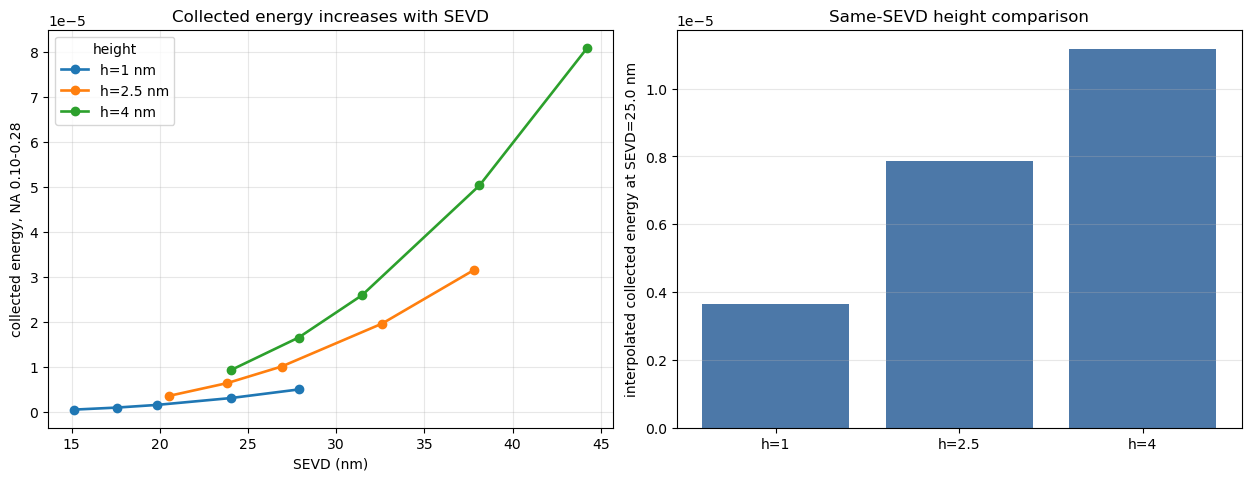

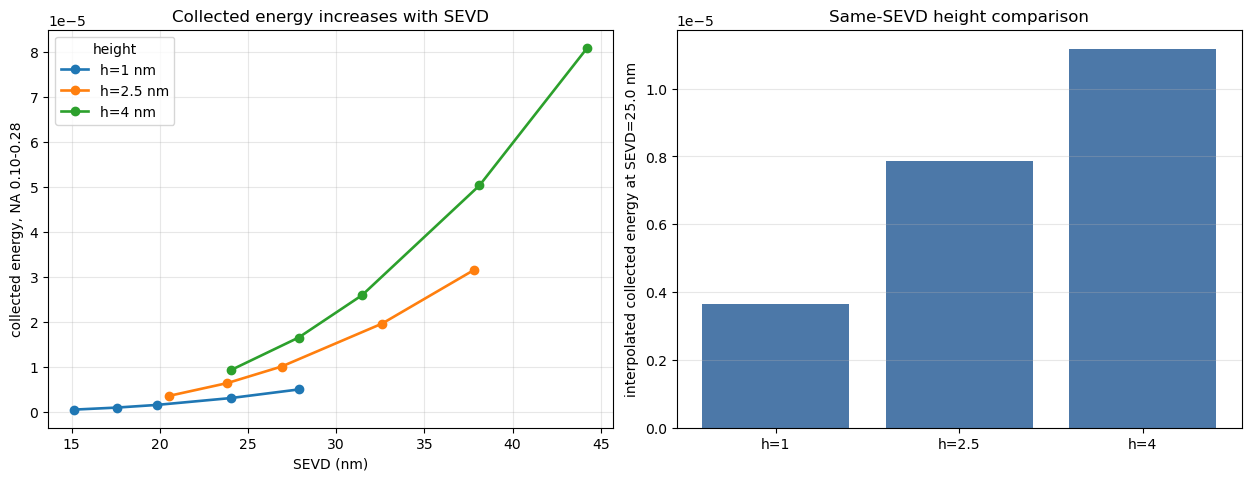

In [7]:
target_sevd_nm = 25.0
fig_sevd, result_table = nas.plot_fdtd_dict_sevd_energy_trends(
    data_fdtd,
    keys,
    pixel_size_um=pixel_size_um,
    wavelength_um=wavelength_um,
    target_sevd_nm=target_sevd_nm,
    na_inner=na_inner,
    na_outer=na_outer,
    reference_field=reference_field,
)
fig_sevd.savefig(output_dir / "na_study_demo_sevd_energy_trends.png", dpi=180, bbox_inches="tight")
fig_sevd

## Production Usage Pattern

Use the same calls with real FDTD fields:

```python
data_fdtd = {
    "h1w40": fdtd_complex_matrix_1,
    "h2.5w60": fdtd_complex_matrix_2,
    "h4w80": fdtd_complex_matrix_3,
}
keys = ["h1w40", "h2.5w60", "h4w80"]

energy = nas.collected_na_energy_from_dict(
    data_fdtd,
    "h1w40",
    pixel_size_um,
    wavelength_um,
    na_inner=0.10,
    na_outer=0.28,
    reference_field=1.0,
)
fig_maps, fig_radial = nas.plot_fdtd_dict_pupil_and_radial(
    data_fdtd,
    keys,
    pixel_size_um,
    wavelength_um,
    reference_field=1.0,
)
```

If your key format is not `h{height}w{width}`, pass `heights_nm={key: value}` and `widths_nm={key: value}` into the plotting wrappers. SEVD is computed through `nas.sevd(h, w)`; replace `def sevd(h, w)` in `na_study.py` with your work-environment formula when needed. If the FDTD matrix already represents only the defect-scattered component, leave `reference_field=None`.